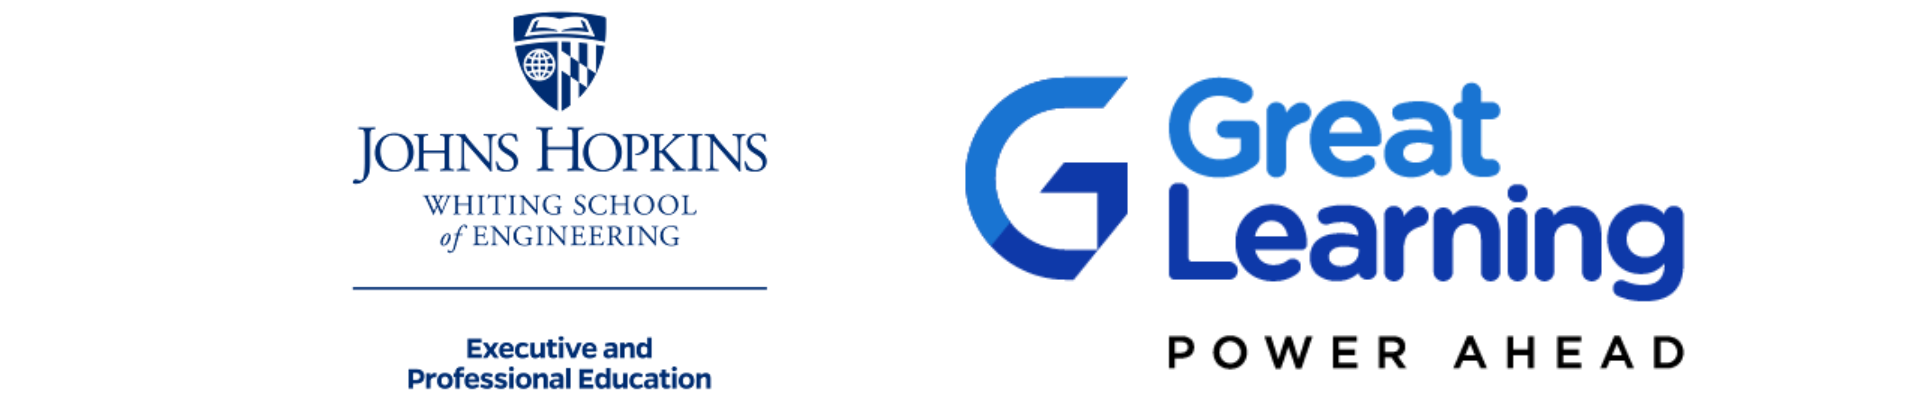

<div style='background: linear-gradient(135deg, #0d2b45 0%, #1f6f78 100%); padding: 32px; border-radius: 14px; color: white;'>
  
  <h1 style='margin: 0; font-size: 2.3em;'><b>🔍 DualLens Analytics — Trustworthy AI Investment Research</b></h1>
  <h2 style='margin: 12px 0 0 0; font-weight: 300;'>Grounded RAG · LLM-as-Judge Evaluation · Self-Improving Prompts (DSPy + GEPA) · Confidence-Routed Decisions</h2>
  <p style='margin: 18px 0 0 0; font-size: 1.05em;'>Build an AI research system that fuses live financial data with company strategy documents — and, unlike a naive chatbot, <b>measures</b> its own answer quality, <b>optimizes</b> its own prompt against a gold dataset, and <b>routes</b> its final recommendation by confidence so no untrusted answer ever reaches a client.</p>
</div>

## 🎯 **Learning Objectives**

By completing this notebook, you will be able to:

✅ **Fuse quantitative + qualitative data sources** — pull live market data with yfinance and combine it with insights retrieved from unstructured PDF reports.

✅ **Build a metadata-filtered RAG pipeline** — chunk, embed, and store documents in ChromaDB with company tags, so a question about MSFT never gets answered from GOOGL passages.

✅ **Diagnose retrieval separately from generation** — use a gold dataset to measure whether failures come from *fetching the wrong passages* or *answering badly from good passages*.

✅ **Design a 3-metric LLM-as-Judge harness** — score every answer on Groundedness, Context Relevance, and Answer Relevance with machine-readable rubrics, and cross-validate judges against an objective accuracy check.

✅ **Optimize prompts automatically with DSPy + GEPA** — recast the prompt as a typed `dspy.Signature`, drive GEPA with a deterministic gold-set metric, and prove the improvement on **held-out questions the optimizer never saw**.

✅ **Ship decisions with confidence routing** — aggregate evaluation signals into a confidence score and route the final investment ranking: client-ready / flagged / held for human review.

## 📊 **Marking Scheme (Total: 20 Marks)**

<div style='background-color: #fff3e0; padding: 18px; border-radius: 10px; border: 2px solid #ff9800;'>

### 📍 <font color="#c0392b">**Part 1 — Core Pipeline (8 marks)**</font>
<font color="#8e44ad">

- Financial lens — stock history + metrics DataFrame + visualizations — **2 marks**
- Narrative lens — PDF ingestion, chunking with company metadata, ChromaDB vector store — **2 marks**
- Grounded RAG function + 5-query typed test suite (incl. out-of-scope trap) — **3 marks**
- Retrieval diagnostics — gold-set hit-rate with vs. without the company filter — **1 mark**
</font>

### 📍 <font color="#c0392b">**Part 2 — Evaluation (5 marks)**</font>
<font color="#8e44ad">

- Three LLM-as-Judge rubrics (Groundedness, Context Relevance, Answer Relevance) + batch evaluation loop + pass/fail table — **3 marks**
- Objective gold-set accuracy check (`expected_substring`) + per-company breakdown + judge cross-validation — **2 marks**
</font>

### 📍 <font color="#c0392b">**Part 3 — Optimization & Decision Layer (5 marks)**</font>
<font color="#8e44ad">

- DSPy `Signature` + retrieval-aware `Module` + deterministic metric with feedback — **2 marks**
- GEPA compilation + evolved-prompt inspection + before/after comparison on the held-out test split — **2 marks**
- Fused ranking (financial + retrieved insights) + confidence score + routing verdict — **1 mark**
</font>

### 📍 <font color="#c0392b">**Part 4 — Summary & Future Scope (2 marks)**</font>
<font color="#8e44ad">

- Observations & learnings — **1 mark**
- Future scope (what would you build next?) — **1 mark**
</font>
</div>


---

### <font color="red"> **# Important Points To Note** </font>

1. For ALL LLM instances in this project (answerer, judges, DSPy task LM, GEPA reflection LM) use the **`"gpt-4o-mini"`** model only.
2. Look for cells marked **📝 YOUR TASK** — each gives you the function/class **skeleton** (names, signatures, docstrings, and step comments) with **`...` placeholders** where your code goes. Replace every `...` with your implementation; the skeleton tells you exactly what each piece must do.
3. **Do not rename** the skeleton's functions, classes, or variables — later **provided** cells depend on these exact names and will fail otherwise.
4. **💡 Hints** appear inside the trickier tasks. Cells without hints are expected to be within reach.
5. **Do not modify** the provided cells, the evaluation question set, the five typed test questions, or the gold-split parameters (`test_size=0.4`, `random_state=42`) — these keep your run comparable with the model solution released after submission.
6. For project submission, please provide the project in **HTML format.** Refer to the **"Guidelines: Converting IPYNB to HTML Files.pdf"** for instructions. Ensure all **outputs are clearly visible**, and enclose prompts in triple quotes **`"""`** so they remain fully visible after conversion.

---

## 📑 **Table of Contents**

1. [Introduction & Business Problem](#section1)
2. [System Architecture Overview](#section2)
3. [Environment Setup](#section3)
4. [Step 1 — Financial Lens: Market Data & Visualization](#section4)
5. [Step 2 — Narrative Lens: Document Ingestion & Vectorization](#section5)
6. [Step 3 — Grounded Q&A: The RAG Pipeline](#section6)
7. [Step 4 — Quality Control: LLM-as-Judge Evaluation](#section7)
8. [Step 5 — Self-Improvement: Prompt Optimization with DSPy + GEPA](#section8)
9. [Step 6 — Decision Layer: Fused Ranking + Confidence Routing](#section9)
10. [Step 7 — Summary & Future Scope](#section10)

## 📖 **Glossary**

Skim this once before reading the rest — the notebook uses these terms throughout.

<div style='background-color: #f0f4ff; padding: 16px; border-radius: 8px; border-left: 4px solid #1f6f78;'>

### 💼 Domain terms

| Term | Meaning |
|---|---|
| **Market Cap** | Total market value of a company's outstanding shares. |
| **P/E Ratio** | Price-to-Earnings — how much investors pay per dollar of earnings. High P/E = priced for growth. |
| **Dividend Yield** | Annual dividend income as a percentage of the stock price. |
| **Beta** | A stock's volatility relative to the overall market (1.0 = moves with the market). |
| **Grounding** | Forcing every claim in an AI answer to trace back to a source document the firm has verified. |
| **Hallucination** | A confident AI claim that does **not** exist in any source document — the failure that almost shipped to a DualLens client. |
| **Gold dataset** | `golden_retrieval.csv` — 20 questions with verified correct answers (`expected_substring`) drawn from the source PDFs. Our objective measuring stick. |
| **Confidence routing** | Sending outputs down different paths based on measured quality: client-ready / flagged / held for human review. |

</div>

<div style='background-color: #f4f0ff; padding: 16px; border-radius: 8px; border-left: 4px solid #6a3ec9; margin-top: 10px;'>

### 🧠 Technical terms

| Term | Meaning |
|---|---|
| **RAG** | Retrieval-Augmented Generation — fetch the most relevant document passages, then have the LLM answer **only** from them. |
| **Chunk** | A small, overlapping slice of a document (~512 tokens here) — the unit that gets embedded and retrieved. |
| **Embedding** | A numerical "fingerprint of meaning" for a chunk of text. Similar meanings → nearby vectors. |
| **Vector store** | A database (ChromaDB here) that finds chunks whose embeddings are most similar to a question's embedding. |
| **Metadata filter** | Restricting retrieval to chunks tagged with a specific company — our fix for cross-company contamination. |
| **LLM-as-Judge** | Using an LLM with a scoring rubric to grade another LLM's output (1–5 here, with a machine-readable `Score: N` line). |
| **Groundedness** | Judge metric: are the answer's claims actually supported by the retrieved context? |
| **Context Relevance** | Judge metric: did the **retriever** fetch passages that can answer the question? (Evaluates retrieval, not generation.) |
| **Answer Relevance** | Judge metric: does the answer actually address what was asked? |
| **DSPy Signature** | A typed prompt contract — the docstring *is* the prompt, and inputs/outputs are declared fields. |
| **GEPA** | A reflection-based prompt optimizer: score candidates → read failure feedback → rewrite the prompt → keep the winners → repeat. |
| **Reflection LM** | The model inside GEPA that reads the metric's feedback and proposes the next prompt rewrite. |
| **Train/test split** | Letting the optimizer learn from one slice of the gold set (12 questions) and proving generalization on a hidden slice (8 questions). |

</div>

<a name='section1'></a>
## 1️⃣ **Introduction & Business Problem**

### 💼 **The Challenge**

**DualLens Analytics** is a boutique investment research firm. Its analysts answer one deceptively simple question for clients: *"Which technology companies are worth investing in right now?"*

Answering it well requires two lenses at once:

- **The numbers lens** — stock trends, market capitalization, revenue, valuation ratios. Structured, abundant, easy to chart.
- **The narrative lens** — what a company is actually *building* for the future, especially its AI initiatives. This lives in long strategy reports: unstructured, dense, slow to read.

Until recently the narrative lens was manual: 10–12 analyst-hours per company, per refresh, across a five-company universe (**GOOGL, MSFT, IBM, NVDA, AMZN**).

Six months ago the firm piloted an AI assistant — paste the documents into an LLM, ask questions, get answers. It was fast, and it became a liability. In a client-facing report the assistant confidently described an NVDA project timeline **that didn't exist in any source document**. A senior analyst caught it two hours before the report shipped. An internal audit found the same pattern repeatedly:

- Answers that mixed up **which company** a project belonged to
- **Fabricated specifics** (dates, dollar figures) not present in any document
- **No way to tell** a reliable answer from an unreliable one — every answer *sounded* equally confident

The firm's conclusion: the problem was never getting an AI to produce answers. The problem is producing answers you can **trust, measure, and improve**.

### 💡 **The Solution**

**DualLens 2.0** — a RAG system with a built-in quality-control layer and a self-improving prompt:

1. **Grounds every answer in source documents** — retrieval + a strict "answer only from context, else say *I don't know*" contract.
2. **Measures answer quality automatically** — an LLM judge scores every answer on three dimensions, cross-checked against an objective gold dataset.
3. **Improves its own prompt** — GEPA reads failure feedback and rewrites the prompt, with the improvement *proven* on questions the optimizer never saw.
4. **Routes outputs by confidence** — the final investment ranking carries a confidence score; low-confidence outputs are held for human review, never silently trusted.

### 💸 **Cost of Inaction**

One shipped hallucination in a client report risks regulatory scrutiny and the firm's reputation. Reverting to manual reading means the research desk simply cannot scale beyond five companies. The system below is what turns analysts from *document readers* into *reviewers of flagged outputs*.

<a name='section2'></a>
## 2️⃣ **System Architecture Overview**

### 🏗️ **The Evaluation-Driven Pipeline**

Unlike the failed pilot — which generated answers and stopped — every generation stage here is paired with a measurement stage, and the measurements feed back into improving the system.

```
 ┌─────────────────────┐        ┌──────────────────────────┐
 │  STEP 1             │        │  STEP 2                  │
 │  Financial Lens     │        │  Narrative Lens          │
 │  yfinance → charts  │        │  PDFs → chunks → Chroma  │
 │  + metrics table    │        │  (+ company metadata)    │
 └─────────┬───────────┘        └────────────┬─────────────┘
           │                                 │
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 3                  │
           │                    │  Grounded RAG Q&A        │
           │                    │  filtered retrieval +    │
           │                    │  strict-context prompt   │
           │                    └────────────┬─────────────┘
           │                                 │
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 4                  │
           │                    │  Judge Harness (3 LLM    │
           │                    │  metrics) + Gold-set     │
           │                    │  objective accuracy      │
           │                    └────────────┬─────────────┘
           │                                 │ failure feedback
           │                    ┌────────────▼─────────────┐
           │                    │  STEP 5                  │
           │                    │  DSPy + GEPA prompt      │
           │                    │  optimization (train 12, │
           │                    │  prove on held-out 8)    │
           │                    └────────────┬─────────────┘
           │                                 │ optimized RAG
           └────────────────┬────────────────┘
                            │
               ┌────────────▼─────────────┐
               │  STEP 6                  │
               │  Fused Ranking +         │
               │  Confidence Score        │
               │  ✅ client-ready          │
               │  ⚠️ flagged               │
               │  🛑 held for human review │
               └──────────────────────────┘
```

### 🤖 **Cast of Characters (all `gpt-4o-mini`)**

| Role | Job | Settings |
|---|---|---|
| **Answerer LLM** | Generates grounded answers from retrieved context | `temperature=0` (deterministic) |
| **Judge LLM** | Scores answers on the three 1–5 rubrics | `temperature=0`, separate object from the answerer |
| **Task LM (DSPy)** | Runs candidate prompts during GEPA compilation | `temperature=0.1` |
| **Reflection LM (GEPA)** | Reads failure feedback, proposes prompt rewrites | `temperature=1.0` — creative variation helps reflection |

> 💰 **Single-model cost note.** A production setup would typically use a *stronger* model as judge/reflector. We run everything on `gpt-4o-mini` to keep costs minimal — and the design choice that makes this viable is the **deterministic gold-set metric** in Step 5: the optimization loop is scored by free Python (substring checks), not by noisy small-model judge calls. This trade-off is itself a real-world lesson.

### 🔁 **Logical Flow**

1. Build both lenses (Steps 1–2) → 2. Answer questions with grounded RAG (Step 3) → 3. Measure quality with judges + the gold dataset (Step 4) → 4. Let GEPA optimize the prompt against the gold-set metric and prove it generalizes (Step 5) → 5. Fuse both lenses into a ranked recommendation, score its confidence, and route it (Step 6).

<a name='section3'></a>
## 3️⃣ **Environment Setup**

### 3.1 · Install dependencies

In [1]:
# Installing the Libraries
""" !pip install -q --upgrade \
    "langchain>=1.0,<2.0" \
    "langchain-core>=1.0,<2.0" \
    "langchain-community>=0.4.2" \
    "langchain-openai>=0.3.0" \
    "langchain-chroma>=0.2.0" \
    "langchain-text-splitters>=0.3.0" \
    "chromadb>=0.5.0" \
    "pypdf>=4.0.0" \
    "openai>=1.40.0" \
    "tiktoken>=0.7.0" \
    "dspy==3.2.1" \
    "scikit-learn>=1.4" \
    "yfinance>=0.2.40"
print("### Library Installation - Done") """

' !pip install -q --upgrade     "langchain>=1.0,<2.0"     "langchain-core>=1.0,<2.0"     "langchain-community>=0.4.2"     "langchain-openai>=0.3.0"     "langchain-chroma>=0.2.0"     "langchain-text-splitters>=0.3.0"     "chromadb>=0.5.0"     "pypdf>=4.0.0"     "openai>=1.40.0"     "tiktoken>=0.7.0"     "dspy==3.2.1"     "scikit-learn>=1.4"     "yfinance>=0.2.40"\nprint("### Library Installation - Done") '

**Note:** Messages above may appear as errors, but they can be safely ignored. They are caused by minor dependency mismatches in optional packages and do not affect the functionality of this notebook.

### After installation, please **restart the runtime** and **do not re-run the above cell**. Continue execution from the next cell below.

### 3.2 · Load your OpenAI API key

- The `config.json` file should contain the **API_KEY** and **API BASE URL** provided for your account.
- Refer to the **OpenAI Access Token documentation** for how to generate and manage your API keys.
- The `config.json` should look like this:

```
{
    "API_KEY": "your_openai_api_key_here",
    "OPENAI_API_BASE": "https://your_openai_api_base/v1"
}
```

In [2]:
# Load the `config.json` file and extract API key + base URL
import json
import os

file_name = 'config.json'
with open(file_name, 'r') as file:
    config = json.load(file)
    os.environ['OPENAI_API_KEY'] = config.get("API_KEY")           # Loading the API Key
    os.environ["OPENAI_BASE_URL"] = config.get("OPENAI_API_BASE")  # Loading the API Base URL

print("API credentials loaded into the environment.")

API credentials loaded into the environment.


In [3]:
# Quick connectivity check — confirms the key + base URL actually reach a working endpoint
from openai import OpenAI

_client = OpenAI()
_ping = _client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Reply with exactly: OK"}],
    max_tokens=5,
)
print("Connectivity check:", _ping.choices[0].message.content)

Connectivity check: OK


### 3.3 · Configuration & shared imports

One place for every knob the notebook uses. If you change a model or a retrieval depth, change it here.

In [4]:
# Core imports used across the notebook.
import warnings
warnings.filterwarnings('ignore')

import re
import time
import zipfile
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

pd.set_option("display.max_colwidth", 120)

In [5]:
# ---- Models ----------------------------------------------------------
# Single-model setup: gpt-4o-mini everywhere (see the cost note in Section 2).
MODEL_NAME      = "gpt-4o-mini"
EMBEDDING_MODEL = "text-embedding-3-small"

# ---- Companies under coverage ----------------------------------------
COMPANIES = ["GOOGL", "MSFT", "IBM", "NVDA", "AMZN"]

# ---- Retrieval & chunking knobs --------------------------------------
CHUNK_SIZE    = 512   # tokens per chunk (token-based splitting matches what models actually count)
CHUNK_OVERLAP = 64    # tokens shared between neighbouring chunks, so facts at boundaries aren't cut in half
TOP_K         = 4     # chunks retrieved per question

# ---- Evaluation & routing policy --------------------------------------
PASS_THRESHOLD       = 4      # a judge metric "passes" at >= 4 out of 5
CONF_CLIENT_READY    = 80     # confidence >= 80  -> ✅ client-ready
CONF_FLAGGED         = 60     # 60 <= conf < 80   -> ⚠️ flagged for awareness
                              # conf < 60         -> 🛑 held for human review

# ---- LLM objects -------------------------------------------------------
# Answerer — generates the RAG response. temperature=0 keeps answers stable
# and grounded; max_tokens caps response length.
llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=1024)

# Judge — a SEPARATE object so the evaluation role is explicit. In production
# this would be a stronger model; here it shares gpt-4o-mini for cost, which
# is exactly why Step 4 cross-validates the judges against the gold dataset.
judge_llm = ChatOpenAI(model=MODEL_NAME, temperature=0, max_tokens=600)

print(f"Configured: answerer={MODEL_NAME}, judge={MODEL_NAME}, embeddings={EMBEDDING_MODEL}")

Configured: answerer=gpt-4o-mini, judge=gpt-4o-mini, embeddings=text-embedding-3-small


<a name='section4'></a>
## 4️⃣ **Step 1 — Financial Lens: Market Data & Visualization**

The quantitative half of DualLens. We pull three years of price history plus five headline financial metrics for the coverage universe, and visualize them. These numbers feed the fused ranking in Step 6.

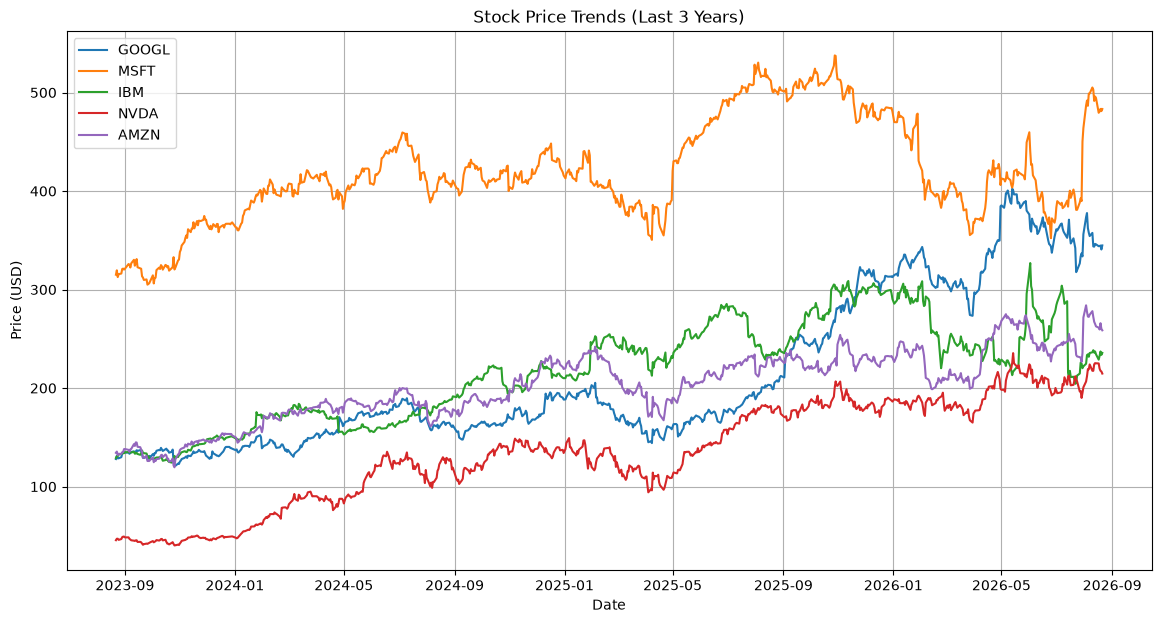

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Three-year price trend chart
# ═══════════════════════════════════════════════════════════════════════════
# One shared figure: the 3-year closing-price trend of all five companies.
# Replace each `...` below.
# ───────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 7))

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    data = ticker.history(period="3y", interval="1d")  # YOUR CODE: fetch this ticker's daily history for the last 3 years
    plt.plot(data.index, data["Close"], label=symbol)     # YOUR CODE: plot the 'Close' series for this company, labelled with its symbol

plt.title("Stock Price Trends (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

#### 💹 Financial Metrics

1. **Market Cap** — total market value of a company's outstanding shares.
2. **P/E Ratio** — how much investors are willing to pay per dollar of earnings.
3. **Dividend Yield** — annual dividend income as a percentage of the stock price.
4. **Beta** — a stock's volatility relative to the overall market.
5. **Total Revenue** — total income generated from business operations.

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Financial metrics DataFrame
# ═══════════════════════════════════════════════════════════════════════════
# Fetch the five headline metrics per company into `fin_df`.
# "Market Cap" is done for you as the worked example — complete the other four.
# 💡 Hint: explore ticker.info's keys; use .get(key, 0) since some companies
#          don't report every field.
# ───────────────────────────────────────────────────────────────────────────
metrics_list = {}

for symbol in COMPANIES:
    ticker = yf.Ticker(symbol)
    info = ticker.info
    metrics_list[symbol] = {
        "Market Cap":     info.get("marketCap", 0),     # worked example
        "P/E Ratio":      info.get("trailingPE", 0),       # YOUR CODE
        "Dividend Yield": info.get("dividendYield", 0),   # YOUR CODE
        "Beta":           info.get("beta", 0),            # YOUR CODE
        "Total Revenue":  info.get("totalRevenue", 0),    # YOUR CODE
    }

# Convert to a DataFrame (companies as the index) and make it readable:
fin_df = pd.DataFrame(metrics_list).T
fin_df["Market Cap"]    = fin_df["Market Cap"] / 1e9     # YOUR CODE: rescale to USD billions
fin_df["Total Revenue"] = fin_df["Total Revenue"] / 1e9  # YOUR CODE: rescale to USD billions
fin_df = fin_df.round(2)

fin_df

,Market Cap,P/E Ratio,Dividend Yield,Beta,Total Revenue
GOOGL,4217.13,17.30,0.26,1.24,445.87
MSFT,3588.32,26.95,0.75,1.10,331.84
IBM,222.04,20.91,2.87,0.70,69.09
NVDA,5200.73,32.88,0.47,2.22,253.49
AMZN,2789.66,20.79,0.00,1.45,775.68


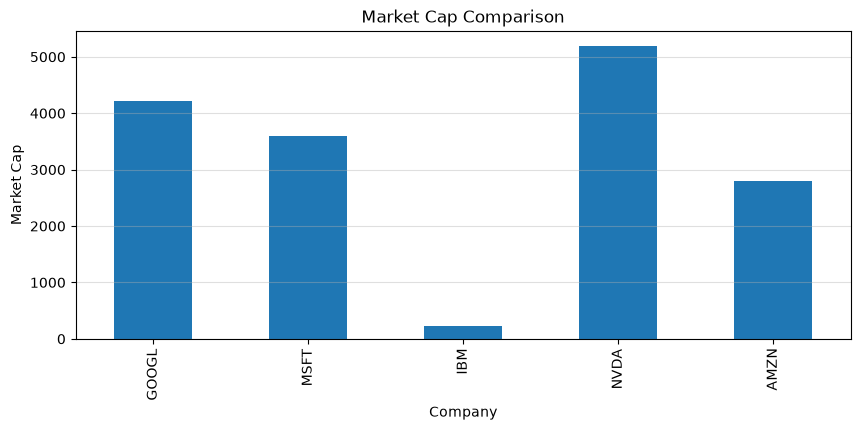

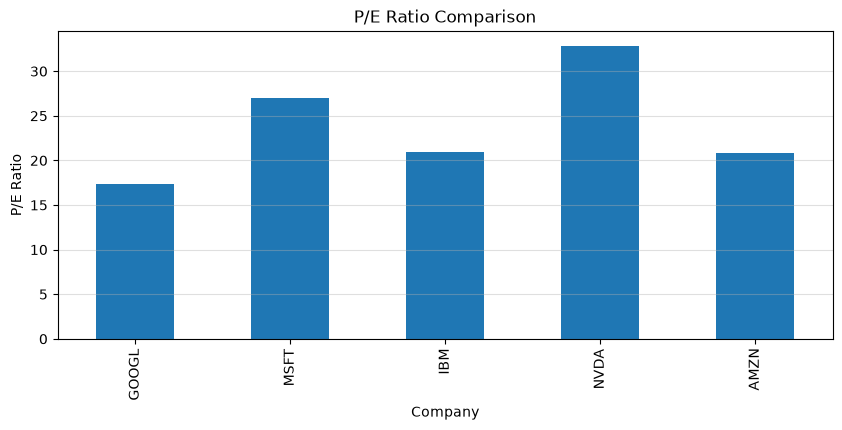

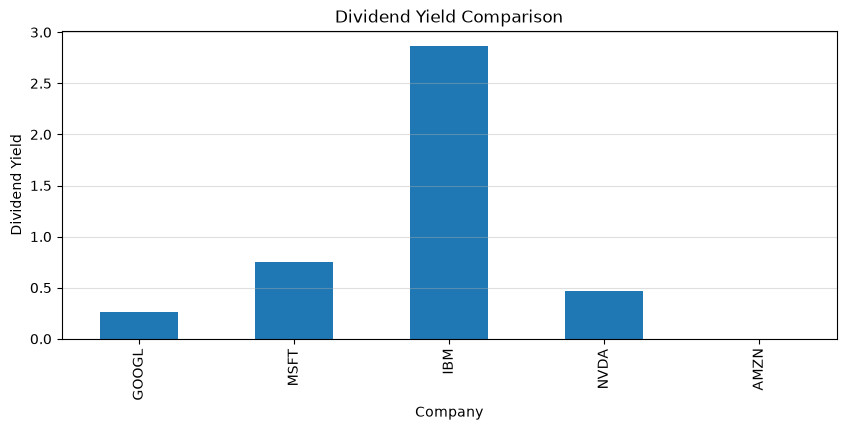

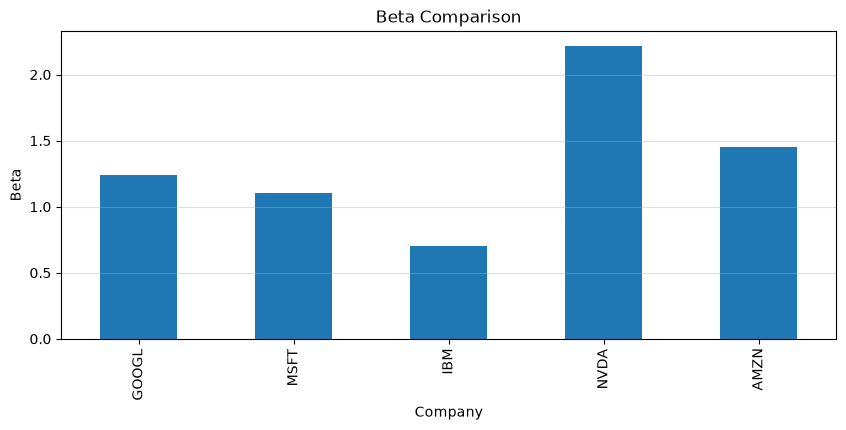

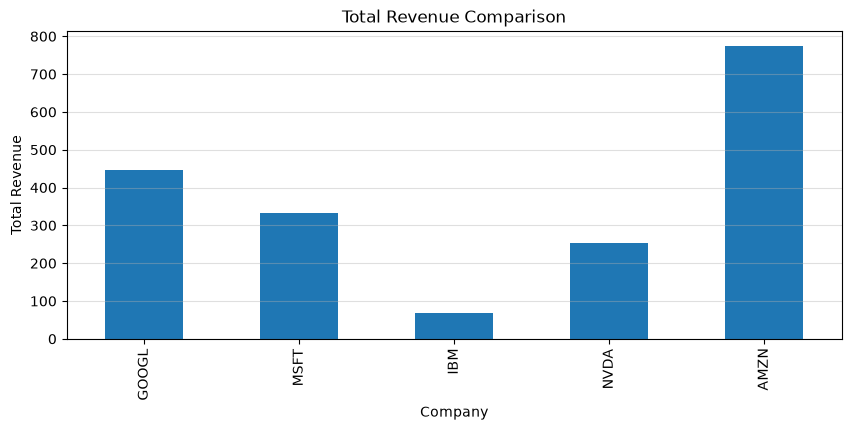

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Per-metric comparison charts
# ═══════════════════════════════════════════════════════════════════════════
# One bar chart per metric, comparing all five companies.
# ───────────────────────────────────────────────────────────────────────────
metrics_to_plot = ["Market Cap", "P/E Ratio", "Dividend Yield", "Beta", "Total Revenue"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    fin_df[metric].plot(kind="bar")  # YOUR CODE: bar chart of fin_df[metric] across companies
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xlabel("Company")
    plt.grid(axis='y', alpha=0.4)
    plt.show()

### 🔎 Your Observations — The Financial Lens

*Write 2–4 bullets. Consider:*
- *Which company do the metrics suggest is "priced for growth", and which looks like a defensive/dividend profile? What evidence?*
- *What investment-relevant question can these numbers NOT answer — and where would that answer live instead?*
- *Note: yfinance returns live data, so describe the pattern you actually see in your run.*

**Response:**

- NVIDIA looks most priced for growth, with the highest market cap ($5,200.73B), P/E (32.88), and beta (2.22), while IBM has the clearest defensive profile through its 2.87% dividend yield and 0.70 beta.
- Amazon generated the most revenue ($775.68B) but paid no dividend; these financial measures compare scale, valuation, and risk, but they do not establish the quality of each company's AI strategy.

<a name='section5'></a>
## 5️⃣ **Step 2 — Narrative Lens: Document Ingestion & Vectorization**

The qualitative half. Five PDF reports (one per company) describing each organization's AI initiatives — summaries, objectives, timelines, investments, risks.

**The one design decision that matters most in this section:** every chunk gets a `company` **metadata tag** derived from its source filename. In the failed pilot, a question about MSFT could be answered from GOOGL passages because all documents lived in one undifferentiated pool. The tag is what lets us *filter* retrieval per company in Step 3 — and *measure* how much that filter helps.

In [9]:
# 📂 Unzip the AI-initiative documents into the working directory.
ZIP_PATH    = "Project_Datafiles.zip"
EXTRACT_DIR = "."
PDF_DIR     = "Companies-AI-Initiatives"

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

pdf_files = sorted(f for f in os.listdir(PDF_DIR) if f.endswith(".pdf"))
print("Documents found:", pdf_files)

Documents found: ['AMZN.pdf', 'GOOGL.pdf', 'IBM.pdf', 'MSFT.pdf', 'NVDA.pdf']


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Load PDFs and tag every page with its company
# ═══════════════════════════════════════════════════════════════════════════
# This tag is what makes company-filtered retrieval possible in Step 3 — the
# fix for the pilot's company-mix-up failures. (It's also why we load each
# file individually instead of using PyPDFDirectoryLoader.)
# ───────────────────────────────────────────────────────────────────────────
documents = []

for fname in pdf_files:
    ticker = fname.replace(".pdf", "")     # "MSFT.pdf" -> "MSFT"
    loader = PyPDFLoader(os.path.join(PDF_DIR, fname))  # YOUR CODE: a PyPDFLoader for this file's full path
    pages  = loader.load()                          # YOUR CODE: load the file (one Document per page)
    for page in pages:
        page.metadata["company"] = ticker       # YOUR CODE: set this page's "company" metadata to the ticker
    documents.extend(pages)

print(f"Loaded {len(documents)} pages across {len(pdf_files)} companies.")

Loaded 44 pages across 5 companies.


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Token-based chunking
# ═══════════════════════════════════════════════════════════════════════════
# Split the tagged pages into overlapping, token-sized chunks. Token-based
# splitting aligns chunk sizes with what the models actually count, and
# splitting Documents (not raw text) carries your company tag onto every chunk.
# 💡 Hint: the splitter has a class method for tiktoken-based sizing
#          ('cl100k_base'), and a method that splits Document objects while
#          preserving their metadata.
# ───────────────────────────────────────────────────────────────────────────
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name='cl100k_base',
    chunk_size=CHUNK_SIZE,        # YOUR CODE: use the constant from Section 3.3
    chunk_overlap=CHUNK_OVERLAP,  # YOUR CODE: use the constant from Section 3.3
)

chunks = text_splitter.split_documents(documents)  # YOUR CODE: split `documents` so metadata is preserved
print(f"Total chunks: {len(chunks)}")

Total chunks: 138


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Sanity-check the chunks
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: collections.Counter over each chunk's company metadata is a one-liner.
# ───────────────────────────────────────────────────────────────────────────
chunk_counts = Counter(chunk.metadata["company"] for chunk in chunks)  # YOUR CODE: chunks per company
print("Chunks per company:", dict(chunk_counts))
print()
print("--- Sample chunk (first 400 chars) ---")
print(chunks[0].page_content[:400])  # YOUR CODE: print the first ~400 chars of one chunk
print(chunks[0].metadata)            # YOUR CODE: print that chunk's metadata (confirm the company tag)

Chunks per company: {'AMZN': 29, 'GOOGL': 22, 'IBM': 27, 'MSFT': 27, 'NVDA': 33}

--- Sample chunk (first 400 chars) ---
Amazon
 
is
 
a
 
global
 
technology
 
and
 
e-commerce
 
giant
 
that
 
uses
 
AI
 
to
 
enhance
 
almost
 
every
 
part
 
of
 
its
 
business.
 
In
 
retail,
 
AI
 
powers
 
product
 
recommendations,
 
dynamic
 
pricing,
 
fraud
 
detection,
 
and
 
supply
 
chain
 
optimization,
 
making
 
shopping
 
faster
 
and
 
more
 
personalized.
 
Amazon
 
Web
 
Services
 
(AWS)
 
offers
 
AI
 
and
 
m
{'producer': 'Skia/PDF m142 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'AI Initiatives', 'source': 'Companies-AI-Initiatives\\AMZN.pdf', 'total_pages': 9, 'page': 0, 'page_label': '1', 'company': 'AMZN'}


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Embed and store in ChromaDB
# ═══════════════════════════════════════════════════════════════════════════
embedding_model = OpenAIEmbeddings(model=EMBEDDING_MODEL)  # YOUR CODE: the EMBEDDING_MODEL constant

vectorstore = Chroma.from_documents(
    chunks,                                     # YOUR CODE: your chunks
    embedding_model,                            # YOUR CODE: your embedding model
    collection_name="ai_initiatives",
)

print(f"Vector store ready with {vectorstore._collection.count()} embedded chunks.")

Vector store ready with 138 embedded chunks.


### 🔎 Your Observations — Ingestion & Vectorization

*Write 2–3 bullets. Consider:*
- *Are chunk counts balanced across companies, and why would an imbalance distort retrieval?*
- *The five companies describe their AI work in very similar language ("cloud AI platform", "foundation models"). What does the metadata tag guarantee that embedding similarity alone might not — and in which kinds of queries does that guarantee matter most?*
- *What trade-off do CHUNK_SIZE / CHUNK_OVERLAP control?*

**Response:**

- The 138 chunks were moderately uneven-GOOGL had 22 versus NVDA's 33, with AMZN 29 and IBM/MSFT 27 each-so larger document sets could otherwise receive more retrieval opportunities.
- Preserving the company tag guarantees company isolation when similar AI language appears across reports, while the 512-token size and 64-token overlap balance contextual completeness against retrieval precision and duplicated text.

<a name='section6'></a>
## 6️⃣ **Step 3 — Grounded Q&A: The RAG Pipeline**

### 6.1 · Prompt design

The grounding contract lives in the system prompt: the model may use **only** the supplied context (marked `###Context`), must answer the question (marked `###Question`), and must reply exactly **"I don't know."** when the context lacks the answer. This is the guardrail the failed pilot never had — it converts "confident fabrication" into an honest, detectable miss.

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the v1.0 grounding system prompt
# ═══════════════════════════════════════════════════════════════════════════
# Write the rules INSIDE the triple quotes. The prompt must instruct the model to:
#   • Use ONLY the information in the supplied context
#   • Respond EXACTLY with: "I don't know." when the context lacks the answer
#   • Never reference the context's structure (no "based on the context...")
#
# ⚠️ Keep it MINIMAL — resist adding extra instructions. This is deliberately
#    your v1.0: Step 4 will measure its weaknesses and Step 5 will let GEPA
#    evolve it. Hand-tuning it now destroys the experiment.
# ───────────────────────────────────────────────────────────────────────────
qna_system_message = """
Answer only using the supplied context. If the context is insufficient, answer exactly: I don't know.
Do not invent facts or use outside knowledge. Answer directly without phrases such as 'based on the context' or 'according to the supplied context'.
"""

In [15]:
# User message template — slots the retrieved context and the user question into a single turn
qna_user_message_template = """
###Context
{context}

###Question
{question}
"""

### 6.2 · Company-filtered retrieval

`retrieve()` is the single retrieval doorway for the whole notebook. Pass a `company` ticker and Chroma restricts the similarity search to that company's chunks; pass `None` (for cross-company questions) and it searches the full pool.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Build the retrieval helper
# ═══════════════════════════════════════════════════════════════════════════
# Every retrieval in this notebook goes through retrieve().
# 💡 Hint: vectorstore.similarity_search() accepts a `filter` argument that
#          takes a metadata dictionary.
# ───────────────────────────────────────────────────────────────────────────
def retrieve(question: str, company: str | None = None, k: int = TOP_K):
    """Return the top-k most similar chunks, optionally restricted to one company.

    Args:
        question: Natural-language question to embed and search with.
        company:  Ticker like "MSFT" to filter on, or None for the full pool.
        k:        Number of chunks to return.
    """
    search_filter = {"company": company} if company is not None else None  # YOUR CODE
    return vectorstore.similarity_search(question, k=k, filter=search_filter)  # YOUR CODE


def format_context(docs) -> str:
    """Join retrieved chunks into a single context string."""
    return "\n\n".join(doc.page_content for doc in docs)    # provided

In [17]:
# 🧪 Demonstrate retrieval end-to-end before wiring the LLM in:
# ask an MSFT question, confirm every returned chunk is tagged MSFT.
demo_question = "What is Microsoft's flagship AI assistant product?"
demo_chunks = retrieve(demo_question, company="MSFT")

print(f"Retrieved {len(demo_chunks)} chunks. Company tags:",
      [c.metadata["company"] for c in demo_chunks])
print()
print("--- First chunk (first 400 chars) ---")
print(demo_chunks[0].page_content[:400])

Retrieved 4 chunks. Company tags: ['MSFT', 'MSFT', 'MSFT', 'MSFT']

--- First chunk (first 400 chars) ---
Microsoft,
 
founded
 
in
 
1975,
 
is
 
a
 
global
 
technology
 
leader
 
specializing
 
in
 
software,
 
cloud
 
computing,
 
AI,
 
and
 
enterprise
 
solutions.
 
The
 
company
 
has
 
aggressively
 
expanded
 
its
 
AI
 
capabilities
 
through
 
initiatives
 
such
 
as
 
Azure
 
AI,
 
OpenAI
 
partnership
 
integrations,
 
and
 
proprietary
 
models
 
like
 
Copilot,
 
which
 
enhance
 
produ


### 6.3 · The RAG function

In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The grounded RAG function: retrieve -> assemble -> answer
# ═══════════════════════════════════════════════════════════════════════════
qna_prompt = ChatPromptTemplate.from_messages([
    ("system", qna_system_message),
    ("user", qna_user_message_template),
])                                              # provided

def rag_answer(question: str, company: str | None = None) -> str:
    """Answer a question using retrieval-augmented generation.

    Args:
        question: The user's natural-language question.
        company:  Optional ticker to restrict retrieval to one company's documents.
    Returns:
        The model's answer, grounded in the retrieved context.
    """
    relevant_chunks = retrieve(question, company=company)  # YOUR CODE: retrieve, passing the company filter through
    context = format_context(relevant_chunks)              # YOUR CODE: format the chunks into one context string

    messages = qna_prompt.format_messages(context=context, question=question)  # YOUR CODE
    response = llm.invoke(messages)  # YOUR CODE: invoke `llm` with the messages
    return response.content

### 6.4 · Typed test suite

Five queries, each probing a different capability. (These are smoke tests for *behaviour*; the rigorous *measurement* happens in Step 4.)

### Example 1: Factual lookup — a single specific fact from one company's document.

In [19]:
# Example 1: factual lookup (single fact, single company)
print(rag_answer("What is Microsoft's flagship AI assistant product brand?", company="MSFT"))

Microsoft 365 Copilot.


### Example 2: Listing question — can retrieval surface multiple related facts in one answer?

In [20]:
# Example 2: listing / multi-fact recall
print(rag_answer("What are the main AI initiatives NVIDIA is working on?", company="NVDA"))

The main AI initiatives NVIDIA is working on include Project G-Assist, which is an on-device AI assistant for GeForce RTX PCs, and DLSS 4, which is an AI-driven image upscaling and frame generation technology designed to enhance gaming performance and visual fidelity.


### Example 3: Cross-company comparison — retrieval over the **full pool** (company=None), since the question spans two companies.

In [21]:
# Example 3: cross-company comparison — no filter, the question itself names both companies
print(rag_answer("How does Google's AI focus differ from Microsoft's AI focus?", company=None))

Google's AI focus emphasizes enhancing user experience, automating workflows, enabling real-time decision-making, and driving innovation across various industries, with a strong emphasis on responsible AI development and ethical considerations. In contrast, Microsoft's AI focus is centered on streamlining workflows, improving decision-making, and driving digital transformation, while also prioritizing responsible AI deployment, security, and compliance with ethical and regulatory standards.


### Example 4: Multi-hop synthesis — connecting facts across chunks of the same document.

In [22]:
# Example 4: multi-hop synthesis — links Amazon's customer-facing platform to its in-house foundation model
print(rag_answer("What is Amazon's foundation-model platform, and what foundation model has Amazon developed in-house?", company="AMZN"))

Amazon's foundation-model platform is called Amazon Bedrock. The foundation model that Amazon has developed in-house is named Olympus.


### Example 5: Out-of-scope trap — validates the **"I don't know"** guardrail. The documents describe AI initiatives, not quarterly financials, so the only correct answer is an honest miss.

In [23]:
# Example 5: out-of-scope — tests the "I don't know" guardrail
print(rag_answer("What was IBM's exact revenue in the third quarter of 2025?", company="IBM"))

I don't know.


### 6.5 · Retrieval diagnostics with the gold dataset

`golden_retrieval.csv` contains **20 questions** (4 per company), each with:

| Column | Meaning |
|---|---|
| `question` | A question answerable from exactly one company's document |
| `ticker_hint` | Which company's document holds the answer |
| `expected_substring` | A short, verified token (e.g., *Copilot*, *Granite*, *Bedrock*) that a correct answer **must** contain |

Here we use it to answer a question the judges in Step 4 *cannot* answer on their own: **when the system fails, is it the retriever's fault or the generator's fault?** We check whether the expected token appears in the *retrieved chunks* (before any LLM is involved) — with the company filter on vs. off.

In [24]:
# 📂 Load the gold dataset
gold = pd.read_csv("golden_retrieval.csv")
print(f"{len(gold)} gold questions, balanced across companies:")
print(gold["ticker_hint"].value_counts().to_dict())
gold.head()

20 gold questions, balanced across companies:
{'MSFT': 4, 'GOOGL': 4, 'IBM': 4, 'NVDA': 4, 'AMZN': 4}


,question,ticker_hint,expected_substring
0,What is Microsoft's flagship AI assistant product brand?,MSFT,Copilot
1,Which Microsoft cloud platform hosts AI services?,MSFT,Azure
2,What is Microsoft's AI development platform for foundation models?,MSFT,Foundry
3,Which Microsoft tool delivers AI-assisted code completion?,MSFT,IntelliCode
4,What is Google's primary foundation-model family?,GOOGL,Gemini


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Retrieval-only diagnostic: filter ON vs filter OFF
# ═══════════════════════════════════════════════════════════════════════════
# An LLM-FREE measurement of the retriever using the gold dataset: you write
# the per-question diagnostic; the loop and summary are provided.
# 💡 Hint: lowercase both sides before the substring check.
# ───────────────────────────────────────────────────────────────────────────
def retrieval_diagnostic(row, use_filter: bool) -> dict:
    """For one gold row: did the expected token reach the retrieved chunks,
    and (for unfiltered retrieval) what share of chunks belong to the right company?"""
    company = row["ticker_hint"] if use_filter else None  # YOUR CODE
    docs    = retrieve(row["question"], company=company)  # YOUR CODE
    text    = format_context(docs).lower()                    # YOUR CODE
    return {
        "hit":    row["expected_substring"].lower() in text,  # YOUR CODE
        "purity": (sum(doc.metadata.get("company") == row["ticker_hint"] for doc in docs) / len(docs)) if docs else 0.0,
    }

# ── Provided: run the diagnostic over the whole gold set ──────────────────────
diag_rows = []
for _, row in gold.iterrows():
    with_f    = retrieval_diagnostic(row, use_filter=True)
    without_f = retrieval_diagnostic(row, use_filter=False)
    diag_rows.append({
        "ticker":                row["ticker_hint"],
        "expected":              row["expected_substring"],
        "hit_with_filter":       with_f["hit"],
        "hit_without_filter":    without_f["hit"],
        "purity_without_filter": round(without_f["purity"], 2),
    })

diag_df = pd.DataFrame(diag_rows)
print(f"Retrieval hit-rate WITH company filter   : {diag_df['hit_with_filter'].mean():.0%}")
print(f"Retrieval hit-rate WITHOUT company filter: {diag_df['hit_without_filter'].mean():.0%}")
print(f"Avg. right-company purity without filter : {diag_df['purity_without_filter'].mean():.0%}")
diag_df

Retrieval hit-rate WITH company filter   : 75%
Retrieval hit-rate WITHOUT company filter: 75%
Avg. right-company purity without filter : 96%


,ticker,expected,hit_with_filter,hit_without_filter,purity_without_filter
0,MSFT,Copilot,True,True,1.00
1,MSFT,Azure,True,True,1.00
2,MSFT,Foundry,True,True,1.00
3,MSFT,IntelliCode,True,True,1.00
4,GOOGL,Gemini,True,True,0.75
5,GOOGL,TPU,False,False,1.00
6,GOOGL,DeepMind,True,True,1.00
7,GOOGL,Astra,True,True,1.00
8,IBM,watsonx,True,True,1.00
9,IBM,Granite,True,True,1.00


### 🔎 Your Observations — RAG Pipeline & Retrieval Diagnostics

*Write 3–4 bullets. Consider:*
- *Did the guardrail behave on your Example 5? Why is an honest miss safer than a confident fabrication?*
- *Compare the with-filter and without-filter hit-rates and the purity number. Did the filter change the result on THIS gold set — and if not, why not? (Look at how the gold questions are phrased.) When would the filter still earn its keep?*
- *Any gold questions where the expected token never reached the retrieved chunks at all? What does that imply about what prompt optimization can and cannot fix later?*

**Response:**

- Filtered and unfiltered retrieval both achieved 75% hit rate; unfiltered purity was still high at 96%, but metadata filtering guarantees company isolation when semantically similar reports would otherwise mix evidence.
- The IBM out-of-scope probe correctly returned "I don't know.", while TPU, Quantum, NIM, Flamingo, and Trainium never reached the retrieved context, placing those failures beyond what prompt optimization alone can repair.

<a name='section7'></a>
## 7️⃣ **Step 4 — Quality Control: LLM-as-Judge Evaluation**

A single good answer is not evidence of a good system. We now measure quality two complementary ways:

- **4A — Subjective (LLM-as-Judge):** three rubric-driven 1–5 scores per answer — **Groundedness**, **Context Relevance**, **Answer Relevance** — over a typed evaluation set that includes one designed-to-fail probe.
- **4B — Objective (gold dataset):** run all 20 gold questions through the pipeline and check the `expected_substring` — a binary, judge-free accuracy number.

Why both? Judges can assess *qualities* (is this grounded? is this relevant?) that no substring can capture — but a `gpt-4o-mini` judge is itself fallible. The objective check cross-validates the judges, and the judges explain *what kind* of failure the objective check found.

### **Evaluation Question Set (4A)**

| # | Type | Why it's in the set |
|---|------|---------------------|
| **Q1** | Easy factual | Baseline — should score high on all three metrics |
| **Q2** | Listing / multi-fact | Tests whether retrieval surfaces enough context for a multi-fact answer |
| **Q3** | Cross-company synthesis | Tests reasoning over an unfiltered, multi-company retrieval |
| **Q4** | **Out-of-scope (expected to fail)** | Asks for financial data the documents don't contain. Should trigger the guardrail and score low on context- and answer-relevance. |
| **Q5** | Specific detail | Tests precision — concrete names/timelines rather than paraphrase |

If every question scored 5/5, the rubric would not be measuring anything — a documented failure case (Q4) is what proves the evaluation is discriminative.

In [26]:
# Five evaluation questions with their retrieval scope. Q4 is intentionally
# unanswerable from the source so we can observe the rubric correctly
# penalising context-relevance and answer-relevance.
evaluation_set = [
    {"question": "What is Google's primary foundation-model family?",                          "company": "GOOGL"},
    {"question": "What are the main AI initiatives IBM is pursuing?",                          "company": "IBM"},
    {"question": "How does NVIDIA's AI strategy differ from Amazon's AI strategy?",            "company": None},
    {"question": "What was Microsoft's total AI revenue for fiscal year 2025?",                "company": "MSFT"},   # out-of-scope trap
    {"question": "What timelines are mentioned for Amazon's foundation-model initiatives?",    "company": "AMZN"},
]

### **Judge Rubric 1 — Groundedness** · *Are the answer's claims actually supported by the retrieved context?*

In [27]:
# User-side template for the groundedness judge — supplies question, context and answer
groundedness_evaluation_message_template = """
###Question
{question}

###Context
{context}

###Answer
{answer}
"""

# System prompt for the groundedness judge — scores how well the answer is
# derived from the provided context, on a 1-5 scale.
# The final "Score: N" line makes the rating machine-readable for the batch evaluator.
groundedness_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question, the context used by the AI system, and the AI-generated answer.
In the input, the question begins with ###Question, the context begins with ###Context, and the answer begins with ###Answer.

Metric:
Groundedness — the answer should be derived ONLY from the information presented in the context. Claims that do not appear in the context lower the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether each claim in the answer is supported by the context.
2. Then assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Judge Rubric 2 — Context Relevance** · *Did the **retriever** fetch passages capable of answering the question?* (This grades retrieval, not the answer — note its template has no `{answer}` slot.)

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the Context Relevance judge (model it on Rubric 1)
# ═══════════════════════════════════════════════════════════════════════════
# This rubric grades the RETRIEVER, not the answer — so this judge must never
# see the answer. The template and the criteria scale are provided; you write
# the metric definition and instructions, mirroring Rubric 1's structure.
# ───────────────────────────────────────────────────────────────────────────
# Provided: user-side template — question and retrieved context ONLY (no answer)
context_relevance_evaluation_message_template = """
###Question
{question}

###Context
{context}
"""

context_relevance_rater_system_message = """You are tasked with rating the quality of retrieved context for a question-answering system.
You will be presented a question and the context retrieved by the system.
In the input, the question begins with ###Question and the context begins with ###Context.

Metric:
Context Relevance — the retrieved passages should contain enough pertinent information to answer the question. Missing essential facts, unrelated material, or evidence too vague to support an answer lowers the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether the context contains the facts needed to answer the question.
2. Assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Judge Rubric 3 — Answer Relevance** · *Does the answer actually address what was asked?* (No `{context}` slot — this isolates question↔answer fit.)

In [29]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Write the Answer Relevance judge
# ═══════════════════════════════════════════════════════════════════════════
# This rubric grades question<->answer fit in isolation — no context slot. Why?
# ───────────────────────────────────────────────────────────────────────────
# Provided: user-side template — question and answer ONLY
answer_relevance_evaluation_message_template = """
###Question
{question}

###Answer
{answer}
"""

answer_relevance_rater_system_message = """You are tasked with rating AI-generated answers to questions posed by users.
You will be presented a question and the AI-generated answer.
In the input, the question begins with ###Question and the answer begins with ###Answer.

Metric:
Answer Relevance — the answer should directly address the question, cover its key requested aspects, and avoid irrelevant content. Indirect, incomplete, evasive, or off-topic answers lower the score.

Evaluation criteria (1-5):
1 - The metric is not followed at all
2 - The metric is followed only to a limited extent
3 - The metric is followed to a good extent
4 - The metric is followed mostly
5 - The metric is followed completely

Instructions:
1. Briefly explain, step by step, whether the answer directly and completely addresses the question without irrelevant content.
2. Assign a rating using the evaluation criteria.
3. End your response with a line in EXACTLY this format: Score: <N>
"""

### **Running the Evaluation (4A)**

Each question runs through retrieval → generation → all three judges. Every rubric ends with a `Score: <N>` line so the score can be parsed reliably.

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Score parser
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: re.findall with case-insensitive + multiline matching (the inline
#          flags `(?im)` work) — anchor the "Score:" pattern at line start.
# ───────────────────────────────────────────────────────────────────────────
def extract_score(judge_text: str) -> int:
    """Pull the final 1-5 integer score from a judge response.
    Falls back to the last 1-5 mentioned anywhere if the 'Score: N' line is
    missing (defensive); returns 0 if no digit is found."""
    m = re.findall(r"(?im)^\s*Score\s*:\s*([1-5])\s*$", judge_text)  # YOUR CODE
    if m:
        return int(m[-1])
    nums = re.findall(r"(?<!\d)([1-5])(?!\d)", judge_text)  # YOUR CODE
    return int(nums[-1]) if nums else 0

In [31]:
# Compile each rubric as a reusable ChatPromptTemplate so we can format
# per-question inputs in the evaluation loop below.
groundedness_prompt = ChatPromptTemplate.from_messages([
    ("system", groundedness_rater_system_message),
    ("user", groundedness_evaluation_message_template),
])

context_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", context_relevance_rater_system_message),
    ("user", context_relevance_evaluation_message_template),
])

answer_relevance_prompt = ChatPromptTemplate.from_messages([
    ("system", answer_relevance_rater_system_message),
    ("user", answer_relevance_evaluation_message_template),
])

In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The evaluation loop
# ═══════════════════════════════════════════════════════════════════════════
# Run one question through retrieval, generation, and all three judges.
# Note: the groundedness and context-relevance judges must see the SAME
# context the answer was generated from.
# ───────────────────────────────────────────────────────────────────────────
def evaluate_question(question: str, company: str | None) -> dict:
    docs    = retrieve(question, company=company)  # YOUR CODE: retrieve with the company filter
    context = format_context(docs)                 # YOUR CODE: format the context
    answer  = llm.invoke(qna_prompt.format_messages(context=context, question=question)).content

    g = judge_llm.invoke(groundedness_prompt.format_messages(question=question, context=context, answer=answer)).content
    c = judge_llm.invoke(context_relevance_prompt.format_messages(question=question, context=context)).content
    a = judge_llm.invoke(answer_relevance_prompt.format_messages(question=question, answer=answer)).content

    return {
        "question": question,
        "answer": answer,
        "groundedness":      extract_score(g),  # YOUR CODE
        "context_relevance": extract_score(c),  # YOUR CODE
        "answer_relevance":  extract_score(a),  # YOUR CODE
    }

# Provided: run every question through the pipeline.
# 5 questions x (1 RAG + 3 judges) = 20 LLM calls — expect ~30-60 seconds.
judge_results = [evaluate_question(item["question"], item["company"]) for item in evaluation_set]
print("Evaluation complete.")

Evaluation complete.


In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Results table with pass/fail
# ═══════════════════════════════════════════════════════════════════════════
judge_df = pd.DataFrame(judge_results)                              # provided
judge_df.insert(0, "Q#", [f"Q{i+1}" for i in range(len(judge_results))])   # provided

judge_df["pass_all"] = (judge_df[["groundedness", "context_relevance", "answer_relevance"]] >= PASS_THRESHOLD).all(axis=1)

# Show scores only — full questions/answers are inspected in the next cell
judge_df[["Q#", "groundedness", "context_relevance", "answer_relevance", "pass_all"]]

,Q#,groundedness,context_relevance,answer_relevance,pass_all
0,Q1,5,5,5,True
1,Q2,5,5,5,True
2,Q3,1,2,1,False
3,Q4,1,1,1,False
4,Q5,5,4,5,True


In [34]:
# Inspect every question that failed at least one metric — these are the cases
# worth a human review before the system goes anywhere near a client.
for r, qid in zip(judge_results, [f"Q{i+1}" for i in range(len(judge_results))]):
    failed = [
        k for k in ("groundedness", "context_relevance", "answer_relevance")
        if r[k] < PASS_THRESHOLD
    ]
    if not failed:
        continue
    print(f"=== {qid} (failed on: {', '.join(failed)}) ===")
    print(f"Q: {r['question']}")
    print(f"A: {r['answer']}")
    print(f"Scores -> groundedness={r['groundedness']}, "
          f"context_relevance={r['context_relevance']}, "
          f"answer_relevance={r['answer_relevance']}")
    print()

=== Q3 (failed on: groundedness, context_relevance, answer_relevance) ===
Q: How does NVIDIA's AI strategy differ from Amazon's AI strategy?
A: I don't know.
Scores -> groundedness=1, context_relevance=2, answer_relevance=1

=== Q4 (failed on: groundedness, context_relevance, answer_relevance) ===
Q: What was Microsoft's total AI revenue for fiscal year 2025?
A: I don't know.
Scores -> groundedness=1, context_relevance=1, answer_relevance=1



### **4B — Objective Gold-Set Accuracy (the baseline that Step 5 must beat)**

Now the judge-free check: every gold question goes through the v1.0 pipeline (with the company filter from `ticker_hint`), and we test whether the verified token appears in the answer. The results double as our **baseline** — Step 5 stores them and reuses them for the before/after comparison, so we never pay for these calls twice.

In [35]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Objective gold-set baseline (the number Step 5 must beat)
# ═══════════════════════════════════════════════════════════════════════════
# run_gold_set takes ANY answer function (question, ticker) -> str. Designing
# it this way lets Step 5 reuse this exact function for the optimized program —
# no recomputation, no double cost.  (~20 RAG calls — expect a minute or two.)
# ───────────────────────────────────────────────────────────────────────────
def run_gold_set(answer_fn) -> pd.DataFrame:
    """Run every gold question through `answer_fn(question, ticker)` and score hits."""
    rows = []
    for _, row in gold.iterrows():
        ans = answer_fn(row["question"], row["ticker_hint"])  # YOUR CODE
        rows.append({
            "ticker":    row["ticker_hint"],
            "question":  row["question"],
            "expected":  row["expected_substring"],
            "answer":    ans,
            "exact_hit": row["expected_substring"].lower() in ans.lower(),  # YOUR CODE
        })
    return pd.DataFrame(rows)

baseline_gold_df = run_gold_set(lambda question, ticker: rag_answer(question, company=ticker))

# Provided: the baseline numbers
baseline_accuracy = baseline_gold_df["exact_hit"].mean()
print(f"v1.0 BASELINE gold-set accuracy: {baseline_gold_df['exact_hit'].sum()}/{len(baseline_gold_df)}  ({baseline_accuracy:.0%})")
print()
print("Per-company hit-rate:")
print(baseline_gold_df.groupby("ticker")["exact_hit"].mean().round(2))

v1.0 BASELINE gold-set accuracy: 11/20  (55%)

Per-company hit-rate:
ticker
AMZN     0.50
GOOGL    0.75
IBM      0.25
MSFT     0.75
NVDA     0.50
Name: exact_hit, dtype: float64


In [36]:
# 🔍 Inspect the objective misses — what did the v1.0 prompt get wrong?
# These exact failures become the feedback GEPA will learn from in Step 5.
misses = baseline_gold_df[~baseline_gold_df["exact_hit"]]
if misses.empty:
    print("No misses — the baseline already answers every gold question. "
          "(GEPA will then optimize for precision/conciseness rather than recall.)")
else:
    for _, m in misses.iterrows():
        print(f"=== {m['ticker']} | expected token: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"A: {m['answer']}")
        print()

=== MSFT | expected token: 'Foundry' ===
Q: What is Microsoft's AI development platform for foundation models?
A: I don't know.

=== GOOGL | expected token: 'TPU' ===
Q: Which accelerator chip does Google use to train its large models?
A: I don't know.

=== IBM | expected token: 'watsonx' ===
Q: What is IBM's enterprise AI platform branded as?
A: IBM's enterprise AI platform is branded as Watson.

=== IBM | expected token: 'Guardium' ===
Q: What is IBM's data security and governance product family?
A: I don't know.

=== IBM | expected token: 'Quantum' ===
Q: What advanced computing area does IBM emphasise alongside AI?
A: I don't know.

=== NVDA | expected token: 'NIM' ===
Q: Which NVIDIA microservice framework deploys foundation models?
A: I don't know.

=== NVDA | expected token: 'Flamingo' ===
Q: What is the NVIDIA in-game assistance initiative codenamed?
A: Project G-Assist

=== AMZN | expected token: 'Olympus' ===
Q: What is Amazon's internal large foundation-model project codenam

### 🔎 Your Observations — What the Two Evaluations Tell Us

*Write 3–4 bullets. Consider:*
- *Q4 (the out-of-scope probe) should fail some metrics — why is that failure a success? Which metric should it still pass, and what does that tell you about what each metric measures?*
- *Classify every gold-set miss: retrieval failure (cross-check your diag_df from 6.5 — did the token ever reach the context?) vs. generation failure. What's the dominant failure pattern in YOUR run?*
- *Find a case where the judge and the substring check disagree (e.g., Groundedness 5 but exact_hit False). Explain why both can be right — and why we'll hand GEPA the objective signal rather than the judge scores.*
- *State the number Step 5 must beat.*

**Response:**

- The judges passed Q1, Q2, and Q5, but gave Q3 and the out-of-scope Q4 scores below threshold; Q4's safe "I don't know." response still received 1/5 on all rubrics, showing that judge scores can penalize a correct abstention.
- The objective baseline was 11/20 (55%): five misses were retrieval gaps and four occurred despite the token reaching context, so both retrieval and generation mattered and the exact gold signal gave GEPA a clearer target than subjective ratings.

<a name='section8'></a>
## 8️⃣ **Step 5 — Self-Improvement: Prompt Optimization with DSPy + GEPA**

### 📚 Pre-read — How GEPA works (2 minutes)

In Step 4 we *measured* the v1.0 prompt and found a pattern of misses. The traditional fix is an analyst hand-tweaking the prompt by intuition — slow, unscientific, unrepeatable. **GEPA** (Genetic-Pareto prompt optimization, via DSPy) automates it as a loop:

1. **Run** the current prompt on training questions.
2. **Score** each answer with a metric — and collect a plain-English **feedback** string explaining each failure (*"the answer failed to mention 'Copilot'…"*).
3. **Reflect** — a reflection LM reads the feedback and proposes a rewritten prompt.
4. **Select** — keep candidate prompts that score better; repeat within budget.

Two design choices make this section work on a `gpt-4o-mini`-only budget:

- **Deterministic metric.** GEPA's API asks *us* to supply the metric. Ours is a substring check against the gold dataset — free Python, zero LLM calls, zero judge noise. (The NovaTech notebook used LLM judges in its metric because review summaries have no ground truth; *we* have ground truth, so we use it. Same GEPA engine, different metric plugged into the same socket.)
- **Train/test hygiene.** GEPA only sees **12** of the 20 gold questions. The other **8** stay hidden until the very end, when we compare v1.0 vs. the GEPA prompt on them. Improvement on *unseen* questions is proof of generalization, not memorization — the same logic as a train/test split in classical ML.

### 8.1 · DSPy LM configuration

In [37]:
# ── DSPy LM configuration ─────────────────────────────────────────────────────
# DSPy routes every LLM call through LiteLLM, so we point it at the same
# API key / base URL used by the rest of the notebook.
#
# Two LMs are configured because GEPA runs a two-model loop:
#   - task_lm        : runs the candidate RAG prompt during compilation and at
#                      inference time. Low temperature for deterministic outputs.
#   - reflection_lm  : reads the metric's natural-language feedback and proposes
#                      the next prompt mutation. Higher temperature gives the
#                      reflection step useful variation. (Production tip: a
#                      stronger model here usually finds better rewrites; we
#                      stay on gpt-4o-mini for cost — our crisp deterministic
#                      feedback is what keeps a small reflector effective.)
import dspy

task_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 0.1,
    max_tokens  = 1024,
)

reflection_lm = dspy.LM(
    model       = "openai/gpt-4o-mini",
    api_key     = os.environ['OPENAI_API_KEY'],
    api_base    = os.environ["OPENAI_BASE_URL"],
    temperature = 1.0,               # creative variation helps reflection
    max_tokens  = 2048,
)

# Register task_lm globally — every dspy.Predict call routes through it.
dspy.settings.configure(lm=task_lm)
print("DSPy configured. version:", dspy.__version__)

DSPy configured. version: 3.2.1


### 8.2 · Train/test split — 12 questions for GEPA, 8 held out

`stratify=ticker_hint` keeps every company represented on both sides of the split, so neither training nor testing is biased toward any one document.

In [38]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Stratified train/test split of the gold set
# ═══════════════════════════════════════════════════════════════════════════
# Required parameters (do NOT change — comparability with the model solution):
#   test_size=0.4, random_state=42, stratify on ticker_hint
# Self-check: 12 train / 8 test, every company in BOTH splits.
# ───────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    gold,
    test_size=0.4,
    random_state=42,
    stratify=gold["ticker_hint"],
)

# Provided: verify the self-check
print(f"Train: {len(train_df)} questions | Held-out test: {len(test_df)} questions")
print("Train per company:", train_df["ticker_hint"].value_counts().to_dict())
print("Test  per company:", test_df["ticker_hint"].value_counts().to_dict())

Train: 12 questions | Held-out test: 8 questions
Train per company: {'GOOGL': 3, 'NVDA': 3, 'MSFT': 2, 'IBM': 2, 'AMZN': 2}
Test  per company: {'AMZN': 2, 'MSFT': 2, 'IBM': 2, 'NVDA': 1, 'GOOGL': 1}


In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Build the trainset as dspy.Examples
# ═══════════════════════════════════════════════════════════════════════════
# 💡 Hint: .with_inputs(...) separates "fields the program receives" from
#          "fields the metric uses as ground truth". expected_substring must
#          stay metric-only — the program must never see it.
# ───────────────────────────────────────────────────────────────────────────
def make_example(row) -> dspy.Example:
    """Convert one gold-dataset row into a dspy.Example for GEPA."""
    return dspy.Example(
        question           = row["question"],            # YOUR CODE
        ticker_hint        = row["ticker_hint"],         # YOUR CODE
        expected_substring = row["expected_substring"],  # YOUR CODE
    ).with_inputs("question", "ticker_hint")  # YOUR CODE: mark ONLY the program's inputs

# Provided:
dspy_trainset = [make_example(row) for _, row in train_df.iterrows()]
dspy_testset  = [make_example(row) for _, row in test_df.iterrows()]
print(f"DSPy trainset: {len(dspy_trainset)} examples | testset: {len(dspy_testset)} examples")

DSPy trainset: 12 examples | testset: 8 examples


### 8.3 · The RAG program — Signature + Module

A `dspy.Signature` is a typed prompt contract: **the docstring IS the prompt**, and GEPA rewrites that docstring across iterations. We seed it with the same minimal v1.0 instructions from Step 3 — deliberately leaving GEPA the headroom to discover what the misses in Step 4B showed was missing (e.g., *name the specific product*).

The `Module` wraps the signature with our **company-filtered retrieval** inside `forward()` — so GEPA optimizes the prompt of the *real* pipeline, retrieval included.

In [40]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The RAG program: Signature + Module
# ═══════════════════════════════════════════════════════════════════════════
# The DOCSTRING IS THE PROMPT — GEPA rewrites it across iterations. Seed it
# with the SAME minimal v1.0 rules as your qna_system_message; do not enrich
# it (GEPA needs the headroom). Your retrieval stays fixed inside forward(),
# so GEPA optimizes the prompt of the REAL pipeline.
# ───────────────────────────────────────────────────────────────────────────
class GroundedQA(dspy.Signature):
    """Answer only using the supplied context. If the context is insufficient, answer exactly: I don't know.
    Do not invent unsupported facts or use outside knowledge.
    """

    # Provided: the typed I/O contract
    context  : str = dspy.InputField(desc="Retrieved passages from the company's AI-initiative report")
    question : str = dspy.InputField(desc="The user's question")
    answer   : str = dspy.OutputField(desc="The answer, grounded strictly in the context")


class GroundedRAG(dspy.Module):
    """Callable retrieval + answer pipeline. GEPA compiles THIS object."""

    # Provided:
    def __init__(self, k: int = TOP_K):
        super().__init__()
        self.k = k
        self.generate = dspy.Predict(GroundedQA)

    def forward(self, question: str, ticker_hint: str):
        docs = retrieve(question, company=ticker_hint, k=self.k)  # YOUR CODE
        context = format_context(docs)                           # YOUR CODE
        return self.generate(context=context, question=question)  # YOUR CODE

# Provided: sanity check on the first training example
v1_program  = GroundedRAG()
sample      = dspy_trainset[0]
sample_pred = v1_program(question=sample.question, ticker_hint=sample.ticker_hint)
print(f"Q ({sample.ticker_hint}): {sample.question}")
print(f"v1.0 answer: {sample_pred.answer}")
print(f"Expected token: '{sample.expected_substring}' -> hit:",
      sample.expected_substring.lower() in sample_pred.answer.lower())

Q (MSFT): Which Microsoft cloud platform hosts AI services?
v1.0 answer: Azure
Expected token: 'Azure' -> hit: True


### 8.4 · The metric — deterministic score + feedback (with an anti-gaming guard)

GEPA is a **reflection-based** optimizer: a float-only metric reduces it to random search, while rich feedback turns it into a guided rewrite loop. Our metric returns both:

- **Score** — 1.0 if the verified token appears in the answer; 0.0 if not. **Guard:** a hit inside an over-long answer (> 80 words) only earns 0.7 — otherwise GEPA could learn to "win" by dumping every product name it sees in the context into every answer. We want *precise* answers, not keyword stuffing.
- **Feedback** — a targeted sentence the reflection LM can act on (which token was missed, or why the score was docked).

In [41]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The GEPA metric: deterministic score + actionable feedback
# ═══════════════════════════════════════════════════════════════════════════
# Pure Python — no LLM calls anywhere in here. The first branch is the worked
# example; complete the other three. Each branch needs a DIFFERENT, targeted
# feedback sentence the reflection LM can act on — name the missed token
# explicitly.
#
# Scoring rules:
#   1.0  token present (case-insensitive) AND answer <= 80 words   [provided]
#   0.7  token present but answer > 80 words  (ANTI-GAMING guard — without it,
#        GEPA can "win" by dumping every product name into every answer)
#   0.0  answer says "I don't know" though the gold token exists — feedback
#        must say the context DID contain it; refuse only when truly absent
#   0.0  token absent — feedback must name the token and demand the exact
#        product/initiative name, not generic descriptions
#
# 💡 Hint: a float-only metric reduces GEPA to random search — the feedback
#          string is what turns it into a guided rewrite loop.
# ───────────────────────────────────────────────────────────────────────────
MAX_ANSWER_WORDS = 80

def gepa_metric(gold_ex, pred, trace=None, pred_name=None, pred_trace=None):
    """Score + natural-language feedback for GEPA, from the gold dataset."""
    answer   = (pred.answer or "").strip()
    expected = gold_ex.expected_substring
    n_words  = len(answer.split())
    hit      = expected.lower() in answer.lower()

    if hit and n_words <= MAX_ANSWER_WORDS:                       # worked example
        score    = 1.0
        feedback = (f"Correct: the answer names '{expected}' and stays concise "
                    f"({n_words} words). Keep answering with the specific product/initiative name.")
    elif hit:
        score    = 0.7
        feedback = (f"Correct: the answer names '{expected}', but at {n_words} words it is too verbose. "
                    "Answer in 1-3 precise sentences while retaining the specific name.")
    elif "i don't know" in answer.lower():
        score    = 0.0
        feedback = (f"Wrongful refusal: the evidence contains the expected token '{expected}'. "
                    "Say 'I don't know.' only when the retrieved evidence genuinely lacks the answer.")
    else:
        score    = 0.0
        feedback = (f"The answer missed the expected token '{expected}'. Name the specific "
                    "initiative or product from the evidence instead of giving a vague description.")

    return dspy.Prediction(score=score, feedback=feedback)

# Provided: smoke-test on the sanity-check prediction from the previous cell
print(gepa_metric(sample, sample_pred))

Prediction(
    score=1.0,
    feedback="Correct: the answer names 'Azure' and stays concise (1 words). Keep answering with the specific product/initiative name."
)


### 8.5 · GEPA compilation

| Parameter | What it controls |
|---|---|
| `metric` | The feedback-emitting scorer (defined above). |
| `auto` | Budget preset: `"light"` / `"medium"` / `"heavy"`. |
| `reflection_lm` | The LM that proposes prompt mutations. |
| `track_stats` | Records per-iteration scores — useful for diagnostics. |
| `seed` | Reproducibility seed for candidate selection. |

The result is **not a prompt string** — it is a compiled `dspy.Module` whose signature docstring (and possibly a few attached demonstrations) has been rewritten. We persist it with `.save(...)`.

**📌 Note:** the cell below can take **~5 to ~15 minutes** to execute (and makes many `task_lm` calls — but zero judge calls, thanks to the deterministic metric).

In [42]:
# ── Run GEPA optimization ─────────────────────────────────────────────────────
# The evolutionary loop: run candidates on the trainset, read the metric's
# feedback, rewrite the GroundedQA docstring, keep the winners.
from dspy.teleprompt import GEPA

start_time = time.time()

gepa = GEPA(
    metric        = gepa_metric,
    auto          = "light",          # efficient preset; raise to "medium" for a deeper search
    reflection_lm = reflection_lm,
    track_stats   = True,
    seed          = 42,
)

optimised_program = gepa.compile(
    student  = GroundedRAG(),
    trainset = dspy_trainset,
)

optimised_program.save("gepa_optimised_rag.json")
elapsed = time.time() - start_time
print("GEPA compilation complete.")
print("=" * 50)
print(f"Time taken for optimization by GEPA : {elapsed:.1f} seconds")
print("=" * 50)

2026/08/23 17:49:04 INFO dspy.teleprompt.gepa.gepa: Running GEPA for approx 428 metric calls of the program. This amounts to 35.67 full evals on the train set.
2026/08/23 17:49:04 WARNING dspy.teleprompt.gepa.gepa: No valset provided; Using trainset as valset. This is useful as an inference-time scaling strategy where you want GEPA to find the best solutions for the provided tasks in the trainset, as it makes GEPA overfit prompts to the provided trainset. In order to ensure generalization and perform well on unseen tasks, please provide separate trainset and valset. Provide the smallest valset that is just large enough to match the downstream task distribution, while keeping trainset as large as possible.
2026/08/23 17:49:04 INFO dspy.teleprompt.gepa.gepa: Using 12 examples for tracking Pareto scores.
GEPA Optimization:   0%|          | 0/428 [00:00<?, ?rollouts/s]2026/08/23 17:49:05 INFO dspy.evaluate.evaluate: Average Metric: 8.0 / 12 (66.7%)
2026/08/23 17:49:05 INFO dspy.teleprompt.

Average Metric: 3.00 / 3 (100.0%): 100%|██████████| 3/3 [00:00<00:00,  8.70it/s]

2026/08/23 17:49:05 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/08/23 17:49:05 INFO dspy.teleprompt.gepa.gepa: Iteration 1: All subsample scores perfect. Skipping.
2026/08/23 17:49:05 INFO dspy.teleprompt.gepa.gepa: Iteration 1: Reflective mutation did not propose a new candidate
GEPA Optimization:   4%|▎         | 15/428 [00:01<00:39, 10.47rollouts/s]2026/08/23 17:49:05 INFO dspy.teleprompt.gepa.gepa: Iteration 2: Selected program 0 score: 0.6666666666666666



Average Metric: 2.00 / 3 (66.7%): 100%|██████████| 3/3 [00:00<00:00,  6.40it/s] 

2026/08/23 17:49:06 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)
2026/08/23 17:49:06 INFO dspy.teleprompt.gepa.gepa: Iteration 2: Proposed new text for generate: Answer exclusively using the context provided. If the context does not contain the answer, respond with "I don't know," but only if there is no relevant information that can guide the response. Ensure that your answers are brief and directly reference specific product names, initiatives, or platforms when relevant, as this aligns with user expectations for clarity and specificity. Do not create facts or use external knowledge; rely solely on the information given. Aim to maintain conciseness while ensuring completeness. If given feedback, incorporate the correction to improve future responses. Maintain a focus on technology, AI, machine learning, and related frameworks as highlighted in the examples, using any provided timelines, objectives, or summaries to inform your answers.


...

2026/08/23 17:50:02 INFO dspy.evaluate.evaluate: Average Metric: 3.0 / 3 (100.0%)
2026/08/23 17:50:02 INFO dspy.teleprompt.gepa.gepa: Iteration 83: All subsample scores perfect. Skipping.
2026/08/23 17:50:02 INFO dspy.teleprompt.gepa.gepa: Iteration 83: Reflective mutation did not propose a new candidate
GEPA Optimization:  99%|█████████▉| 423/428 [00:58<00:00,  7.42rollouts/s]2026/08/23 17:50:02 INFO dspy.teleprompt.gepa.gepa: Iteration 84: Selected program 1 score: 0.75



Average Metric: 2.00 / 3 (66.7%): 100%|██████████| 3/3 [00:00<00:00,  7.74it/s]

2026/08/23 17:50:02 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)
2026/08/23 17:50:02 INFO dspy.teleprompt.gepa.gepa: Iteration 84: Proposed new text for generate: You are an AI assistant tasked with answering specific questions based on the supplied context. Your responses must adhere to the following guidelines:

1. **Contextual Response**: Use only information from the provided context. If applicable, extract and provide the answer accurately and concisely from the context.

2. **No External Knowledge**: Refrain from including information or facts from outside the provided context. 

3. **Exact Answer**: If insufficient information is available in the context to answer the question, respond with "I don't know." This should be used only when there is genuinely no applicable information in the context.

4. **Clarity and Precision**:
   - Present factual information clearly and accurately.
   - Use specific product, initiative, or technology names whenever possible to av

2026/08/23 17:50:03 INFO dspy.evaluate.evaluate: Average Metric: 2.0 / 3 (66.7%)
2026/08/23 17:50:03 INFO dspy.teleprompt.gepa.gepa: Iteration 84: New subsample score 2.0 is not better than old score 2.0, skipping
GEPA Optimization:  99%|█████████▉| 423/428 [00:59<00:00,  7.15rollouts/s]

GEPA compilation complete.
Time taken for optimization by GEPA : 59.2 seconds


### 8.6 · Inspect the evolved prompt

The "v2.0 prompt" lives inside the compiled program as the signature's rewritten docstring. Compare it with the three-line v1.0 we started from — GEPA's additions are a direct response to the feedback strings (naming specifics, conciseness, when to refuse).

In [43]:
# ── Display the GEPA-evolved prompt ───────────────────────────────────────────
print("=" * 78)
print("v1.0 PROMPT (what we started with):")
print("=" * 78)
print(GroundedQA.__doc__)

for name, predictor in optimised_program.named_predictors():
    print()
    print("=" * 78)
    print(f"v2.0 PROMPT — GEPA-evolved instructions for predictor '{name}':")
    print("=" * 78)
    print(predictor.signature.instructions)
    demos = getattr(predictor, "demos", [])
    print()
    print(f"Few-shot demos attached by GEPA: {len(demos)}")

v1.0 PROMPT (what we started with):
Answer only using the supplied context. If the context is insufficient, answer exactly: I don't know.
    Do not invent unsupported facts or use outside knowledge.
    

v2.0 PROMPT — GEPA-evolved instructions for predictor 'generate':
You are an AI assistant tasked with answering specific questions based only on the supplied context. Your responses must adhere to the following guidelines:

1. **Contextual Response**: Use only information from the provided context. If the context contains the answer to the question, provide the answer accurately and concisely.

2. **No External Knowledge**: Do not bring in information or facts from outside the provided context. 

3. **Exact Answer**: If the context lacks sufficient information to answer the question, respond with "I don't know." Use this response only when there is genuinely no applicable information in the context.

4. **Clarity and Precision**:
   - When the context includes relevant factual inform

**Note:** *Few-shot demos are GEPA's other optimisation lever: high-scoring examples auto-selected and appended to the prompt. Zero here means GEPA judged the instruction rewrite sufficient on its own; raising `auto='medium'` often unlocks them.*

### 8.7 · The proof — before vs. after on the **held-out** 8 questions

The only comparison that counts. The v1.0 baseline answers were already produced in Step 4B (we filter that table down to the test split — no recomputation, no double cost). The v2.0 answers come from the compiled program. Neither prompt has ever seen these 8 questions during optimization.

In [44]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The proof: v1.0 vs v2.0 on the held-out 8
# ═══════════════════════════════════════════════════════════════════════════
# v1.0 answers are REUSED from Step 4B (no recomputation); v2.0 answers come
# from the compiled program. Neither prompt ever saw these 8 questions.
# ───────────────────────────────────────────────────────────────────────────
# Provided: v1.0 baseline answers, filtered down to the held-out questions
v1_test = baseline_gold_df[baseline_gold_df["question"].isin(test_df["question"])].copy()
v1_test = v1_test.set_index("question")

rows = []
for _, row in test_df.iterrows():
    pred      = optimised_program(question=row["question"], ticker_hint=row["ticker_hint"])
    v2_answer = pred.answer  # YOUR CODE: the predicted answer text
    rows.append({
        "ticker":    row["ticker_hint"],
        "question":  row["question"],
        "expected":  row["expected_substring"],
        "v1_hit":    bool(v1_test.loc[row["question"], "exact_hit"]),  # YOUR CODE
        "v2_answer": v2_answer,
        "v2_hit":    row["expected_substring"].lower() in v2_answer.lower(),  # YOUR CODE
    })

compare_df = pd.DataFrame(rows)

# Provided: the before/after verdict
v1_acc = compare_df["v1_hit"].mean()
v2_acc = compare_df["v2_hit"].mean()
print("=" * 60)
print(f"  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)")
print(f"  v1.0 baseline prompt : {compare_df['v1_hit'].sum()}/8  ({v1_acc:.0%})")
print(f"  v2.0 GEPA prompt     : {compare_df['v2_hit'].sum()}/8  ({v2_acc:.0%})")
print("=" * 60)

compare_df[["ticker", "expected", "v1_hit", "v2_hit"]]

  HELD-OUT TEST ACCURACY (8 questions GEPA never saw)
  v1.0 baseline prompt : 4/8  (50%)
  v2.0 GEPA prompt     : 5/8  (62%)


,ticker,expected,v1_hit,v2_hit
0,AMZN,Trainium,False,False
1,NVDA,Flamingo,False,False
2,MSFT,IntelliCode,True,True
3,GOOGL,DeepMind,True,True
4,MSFT,Copilot,True,True
5,AMZN,Bedrock,True,True
6,IBM,Quantum,False,False
7,IBM,Guardium,False,True


In [45]:
# 🔍 Read the cases the optimization actually changed — fixed misses prove the
# evolved instructions work; any regression is worth diagnosing.
changed = compare_df[compare_df["v1_hit"] != compare_df["v2_hit"]]
if changed.empty:
    print("No flips between v1.0 and v2.0 on the held-out set — see Observations below.")
else:
    for _, m in changed.iterrows():
        status = "FIXED ✅" if m["v2_hit"] else "REGRESSED ❌"
        print(f"=== {status} | {m['ticker']} | expected: '{m['expected']}' ===")
        print(f"Q: {m['question']}")
        print(f"v2.0 answer: {m['v2_answer']}")
        print()

=== FIXED ✅ | IBM | expected: 'Guardium' ===
Q: What is IBM's data security and governance product family?
v2.0 answer: IBM's data security and governance product family includes Guardium, specifically the Guardium AI Security enhancements and the Guardium Data Security Center, which focuses on hybrid cloud, AI, and quantum risks. Additionally, it integrates with Watsonx Governance for unified governance and security.



### 🔎 Your Observations — What GEPA Changed and Why

*Write 3–4 bullets. Consider:*
- *Put the v2.0 instructions next to your metric's feedback strings — which feedback does each rewritten line respond to?*
- *Did held-out accuracy improve? Why does a gain on these 8 questions mean more than a gain on the 12 training questions would?*
- *For each residual v2.0 miss: could ANY prompt have fixed it? (Cross-check your diag_df — was it a retrieval failure?) What does that say about how to read the headline score?*
- *What would the optimal prompt have looked like WITHOUT the 80-word anti-gaming guard — and why would that prompt be useless in production?*

**Response:**

- GEPA evolved the prompt to extract exact product or initiative names, stay concise, and refuse only when evidence is genuinely absent; it fixed IBM's Guardium answer without a held-out regression.
- Held-out accuracy improved from 4/8 (50%) to 5/8 (62.5%), while the remaining Trainium, Flamingo, and Quantum misses were retrieval failures, demonstrating that prompt optimization cannot recover evidence absent from the context.

<a name='section9'></a>
## 9️⃣ **Step 6 — Decision Layer: Fused Ranking + Confidence Routing**

The client deliverable: rank the five companies for investment potential using **both lenses** — and attach an honest, evidence-based confidence to the result.

### 9.1 · Build per-company evidence digests (retrieval-based, not a document dump)

The failed pilot's ranking step stuffed *every* document into one prompt. We retrieve a focused digest per company instead — the same disciplined retrieval the rest of the system uses.

In [46]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Per-company evidence digests (retrieval-based, NOT a dump)
# ═══════════════════════════════════════════════════════════════════════════
# Focused evidence beats a raw document dump — shorter prompt, less noise,
# every passage attributable to its company.
# ───────────────────────────────────────────────────────────────────────────
DIGEST_QUERY = "key AI initiatives, strategic investments, timelines, and risks"

company_digests = {}
for ticker in COMPANIES:
    docs = retrieve(DIGEST_QUERY, company=ticker, k=3)  # YOUR CODE
    company_digests[ticker] = "\n".join(f"- {doc.page_content}" for doc in docs)  # YOUR CODE

# Provided: assemble the evidence block for the ranking prompt
digest_block = "\n\n".join(
    f"#### {ticker} — AI Initiative Evidence\n{company_digests[ticker]}"
    for ticker in COMPANIES
)
print(f"Built digests for {len(company_digests)} companies "
      f"({sum(len(v) for v in company_digests.values())} characters of evidence).")

Built digests for 5 companies (14191 characters of evidence).


### 9.2 · The fused ranking call

In [47]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — The fused ranking call
# ═══════════════════════════════════════════════════════════════════════════
# YOU author the system prompt — it must instruct the model to:
#   • analyze the financial data AND the AI-initiative evidence together
#   • rank the five organizations (1 = strongest) by investment potential
#   • justify EVERY rank by explicitly citing at least one financial metric
#     AND at least one NAMED initiative from the evidence
#   • use only the supplied evidence (no outside knowledge)
#   • output a ranked list (1-5) with 2-3 sentence justifications, ending with
#     a one-line caveat naming any company whose evidence felt thin
# ───────────────────────────────────────────────────────────────────────────
ranking_system_message = """
Use both the Financial Data and AI Initiative Evidence to rank all five companies from 1 (strongest) to 5 (weakest) for investment potential.
For every company, write roughly 2-3 sentences that cite at least one explicit financial metric and at least one named AI initiative from the supplied evidence.
Use only the supplied evidence and no outside knowledge. Produce every rank exactly once, then end with one single-line caveat naming any company whose evidence is comparatively thin.
"""

# Provided: the user message fusing both lenses, and the call
ranking_user_message = f"""Using the information below, rank these organizations for investment potential.

---
### 1. Financial Data
{fin_df.to_string()}

---
### 2. AI Initiative Evidence (retrieved from source documents)
{digest_block}
"""

ranking_messages = ChatPromptTemplate.from_messages([
    ("system", ranking_system_message),
    ("user", "{payload}"),
]).format_messages(payload=ranking_user_message)

recommendation = llm.invoke(ranking_messages)
print(recommendation.content)

1. **GOOGL**  
Google's strong investment in AI, particularly through Project Astra, positions it as a leader in AI research and product integration. With a market cap of $4,217.13 billion and a P/E ratio of 17.30, Google is not only financially robust but also focused on enhancing user engagement and creating new revenue streams through its AI initiatives.

2. **MSFT**  
Microsoft's commitment to AI innovation is evident through its Azure AI Foundry Labs, which involves significant investments estimated in the hundreds of millions annually. With a market cap of $3,588.32 billion and a P/E ratio of 26.95, Microsoft is strategically embedding AI across its products, enhancing operational efficiency and maintaining a competitive edge in the cloud market.

3. **NVDA**  
NVIDIA's G-Assist project demonstrates its focus on integrating AI capabilities across its product portfolio, which aligns with its strategic goal of making AI a core capability. The company has a market cap of $5,200.73 b

### 9.3 · Confidence score + routing verdict

A recommendation without a confidence is the pilot's mistake all over again. We aggregate three measured signals into a 0–100 score:

| Signal | Weight | What it certifies |
|---|---|---|
| **Gold-set accuracy (v2.0, held-out)** | 40% | The Q&A engine answers verified questions correctly on unseen data |
| **Judge harness mean (Step 4A, in-scope Qs)** | 30% | The system's answers are grounded, well-retrieved, and relevant |
| **Ranking groundedness (judged now)** | 30% | *This specific deliverable* sticks to the supplied evidence |

Routing policy: **≥ 80 → ✅ CLIENT-READY** · **60–79 → ⚠️ FLAGGED** (send with a reviewer cc'd) · **< 60 → 🛑 HELD** for human review.

In [48]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Signal 3: judge THIS deliverable's groundedness
# ═══════════════════════════════════════════════════════════════════════════
# Reuse your compiled groundedness_prompt against the exact evidence the
# ranking was given.
# ───────────────────────────────────────────────────────────────────────────
ranking_groundedness_raw = judge_llm.invoke(
    groundedness_prompt.format_messages(
        question="Rank the five companies for investment potential using the supplied financial data and AI initiative evidence.",
        context=fin_df.to_string() + "\n\n" + digest_block,  # YOUR CODE
        answer=recommendation.content,                          # YOUR CODE
    )
).content
ranking_groundedness = extract_score(ranking_groundedness_raw)  # YOUR CODE
print(f"Ranking groundedness (1-5): {ranking_groundedness}")

Ranking groundedness (1-5): 5


In [49]:
# ═══════════════════════════════════════════════════════════════════════════
# 📝 YOUR TASK — Confidence score + routing verdict
# ═══════════════════════════════════════════════════════════════════════════
# Three signals (each 0-1), weighted 40 / 30 / 30, routed with the Section 3.3
# constants. Q4 is excluded from the judge mean — its engineered low scores
# measure the guardrail, not system quality.
# ───────────────────────────────────────────────────────────────────────────
in_scope = judge_df[judge_df["Q#"] != "Q4"]                                  # provided

judge_mean_signal = in_scope[["groundedness", "context_relevance", "answer_relevance"]].to_numpy().mean() / 5
gold_signal       = v2_acc
ranking_signal    = ranking_groundedness / 5

confidence = round(100 * (0.40 * gold_signal + 0.30 * judge_mean_signal + 0.30 * ranking_signal), 1)

# YOUR CODE: route using CONF_CLIENT_READY and CONF_FLAGGED ->
#   verdict in {"✅ CLIENT-READY", "⚠️ FLAGGED", "🛑 HELD FOR HUMAN REVIEW"}
#   advice  = a one-line recommended action for that route
if confidence >= CONF_CLIENT_READY:
    verdict, advice = "✅ CLIENT-READY", "Proceed with delivery and retain routine monitoring."
elif confidence >= CONF_FLAGGED:
    verdict, advice = "⚠️ FLAGGED", "Deliver only after a human reviews the flagged evidence and residual misses."
else:
    verdict, advice = "🛑 HELD FOR HUMAN REVIEW", "Do not deliver until retrieval and answer failures are corrected and re-evaluated."

# Provided: the verdict banner
print("=" * 64)
print(f"  COMPONENT SIGNALS")
print(f"  Gold-set accuracy (v2.0, held-out) : {gold_signal:.0%}   (weight 40%)")
print(f"  Judge harness mean (in-scope)      : {judge_mean_signal:.0%}   (weight 30%)")
print(f"  Ranking groundedness               : {ranking_signal:.0%}   (weight 30%)")
print("=" * 64)
print(f"  CONFIDENCE: {confidence} / 100")
print(f"  ROUTING:    {verdict}")
print(f"  ACTION:     {advice}")
print("=" * 64)

  COMPONENT SIGNALS
  Gold-set accuracy (v2.0, held-out) : 62%   (weight 40%)
  Judge harness mean (in-scope)      : 80%   (weight 30%)
  Ranking groundedness               : 100%   (weight 30%)
  CONFIDENCE: 79.0 / 100
  ROUTING:    ⚠️ FLAGGED
  ACTION:     Deliver only after a human reviews the flagged evidence and residual misses.


In [52]:
# 💾 Persist the deliverables — evaluation evidence travels WITH the recommendation.
judge_df.to_csv("evaluation_judge_results.csv", index=False)
baseline_gold_df.to_csv("goldset_baseline_results.csv", index=False)
compare_df.to_csv("goldset_before_after.csv", index=False)

with open("final_recommendation.txt", "w", encoding="utf-8") as f:
    f.write(f"CONFIDENCE: {confidence}/100 — {verdict}\n\n")
    f.write(recommendation.content)

print("Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,")
print("       goldset_before_after.csv, final_recommendation.txt")

Saved: evaluation_judge_results.csv, goldset_baseline_results.csv,
       goldset_before_after.csv, final_recommendation.txt


### 🔎 Your Observations — The Decision Layer

*Write 2–3 bullets. Consider:*
- *Verify the ranking output against its own contract: does every rank cite one financial metric AND one named initiative? Quote a line a reviewer might flag.*
- *Which routing verdict did your run produce, and which component signal pulled it there? What concrete change to the system would move the confidence most?*
- *Why is a system that knows when to say "a human should look at this" deployable long before it's perfect?*

**Response:**

- The ranking satisfied its evidence contract for all five companies and earned groundedness 5/5, while explicitly caveating that `IBM's evidence is comparatively thin.`
- Confidence reached 79.0/100 and routed to `⚠️ FLAGGED`: the 62.5% held-out gold signal was the main constraint versus the 80% judge mean and 100% ranking signal, so retrieval improvements and human review are needed before client-ready delivery.

<a name='section10'></a>
## 🔟 **Step 7 — Summary & Future Scope**

### 📝 **A. Summary / Your Observations about this Project (1 mark)**

> <font color="red">**Your Task**</font> — Write **3–4 substantive bullets** synthesizing what you learned across the whole pipeline. Strong summaries connect results across steps rather than recapping them — for example: what the out-of-scope probe revealed about your metrics, how the retrieval-vs-generation distinction explained both your baseline misses *and* GEPA's ceiling, what the evolved prompt taught you about metric design, or how the single-model constraint shaped the architecture.

*Write your summary here:*

- Trustworthy RAG required measuring retrieval and generation separately: retrieval reached 75%, while the v1 objective gold baseline reached 55%.
- GEPA improved held-out accuracy from 50% to 62.5%, but residual retrieval failures limited what prompt optimization could recover.
- Combining objective accuracy, LLM judges, and ranking groundedness produced 79.0/100 confidence, correctly routing the recommendation as ⚠️ FLAGGED rather than automatically client-ready.

### 🔭 **B. Future Scope (1 mark)**

> <font color="red">**Your Task**</font> — Propose **at least 3 concrete extensions**, each with a short heading and 1–2 sentences on what it adds and why it matters. Think along dimensions like: data freshness, scaling the coverage universe, evaluation hardening, monitoring, multi-agent decomposition, or decision sophistication.

*Write your future scope here:*

#### 1. Fresher Data: Automatically update financial metrics and corporate AI reports with versioning.
#### 2. Better Retrieval: Add hybrid search and reranking to recover evidence currently missed by top-k semantic retrieval.
#### 3. Stronger Evaluation: Expand the gold/adversarial dataset and add production monitoring and human-review feedback.

## 🎉 **Congratulations!**

You've built what the failed pilot was missing — not a chatbot, but a **measured system**:

- A dual-lens research pipeline grounded in verifiable sources
- A retrieval layer whose correctness you *proved* with an LLM-free diagnostic
- A three-metric judge harness cross-validated by an objective gold dataset
- A prompt that **optimized itself** with GEPA — and proved it on held-out questions
- A deliverable that ships with a confidence score and knows when to ask a human

Every later project in this program builds on this discipline: *generate → measure → improve → route*. Keep it.